## 0. 환경설정

In [25]:
from tensorflow.keras.datasets import fashion_mnist, imdb
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Reshape, SimpleRNN, Bidirectional, LSTM
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from nltk.stem import WordNetLemmatizer, PorterStemmer, LancasterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from konlpy.tag import Okt, Kkma
from nltk import sent_tokenize
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
import glob
from collections import Counter


# 1. RNN 

## 1. Many-to-Many (Asymmetric) 모델

In [ ]:
# 실습 1-0 번역 모델 실습
# 정수 인덱스 매핑

docs = ['i love you', 'i hate you', 'i like you', 'i curse you', '나는 당신을 사랑합니다', '나는 당신을 미워합니다', '나는 당신을 좋아합니다', '나는 당신을 저주합니다']

wd2id = {}
id2wd = {}
idx=0

for sent in docs:
    for wd in sent.split():
        if wd2id.get(wd,-1) == -1: # 0부터 시작하니까. -1 로 시작
            wd2id[wd] = idx
            id2wd[idx] = wd
            idx += 1

      # 같지만 다른 방식
      # if wd not in wd2idx:
      #   wd2id[wd] = idx
      #   id2wd[idx] = wd
      #   idx += 1

print(wd2id)
print(id2wd)

{'i': 0, 'love': 1, 'you': 2, 'hate': 3, 'like': 4, 'curse': 5, '나는': 6, '당신을': 7, '사랑합니다': 8, '미워합니다': 9, '좋아합니다': 10, '저주합니다': 11}
{0: 'i', 1: 'love', 2: 'you', 3: 'hate', 4: 'like', 5: 'curse', 6: '나는', 7: '당신을', 8: '사랑합니다', 9: '미워합니다', 10: '좋아합니다', 11: '저주합니다'}


In [4]:
# 실습 1-1  문장을 인덱스 시퀀스로 변환

data = []
for sent in docs :
    tmp=[]
    for wd in sent.split():
        tmp.append(wd2id[wd])
    data.append(tmp)
print(data)

[[0, 1, 2], [0, 3, 2], [0, 4, 2], [0, 5, 2], [6, 7, 8], [6, 7, 9], [6, 7, 10], [6, 7, 11]]


In [9]:
# 실습 1-2 단어를 원-핫 인코딩
# shape (8, 3, 12) = (문장 8개, 문장 내 단어 3개, 단어집합 크기 12)

data_oh=to_categorical(data)

print(data_oh.shape)

x_data = data_oh[:4]
y_data = data_oh[4:]

print(x_data.shape, y_data.shape)

(8, 3, 12)
(4, 3, 12) (4, 3, 12)


In [ ]:
# 실습 2-1 Tokenizer 적용
# 정수 인덱스 매핑

tknzr = Tokenizer()
tknzr.fit_on_texts(docs)
print(tknzr.index_word) # 0이 아닌 1부터 시작함/ 0은 데이터가 없는 경우에 사용됨
print(tknzr.word_index)

{1: 'i', 2: 'you', 3: '나는', 4: '당신을', 5: 'love', 6: 'hate', 7: 'like', 8: 'curse', 9: '사랑합니다', 10: '미워합니다', 11: '좋아합니다', 12: '저주합니다'}
{'i': 1, 'you': 2, '나는': 3, '당신을': 4, 'love': 5, 'hate': 6, 'like': 7, 'curse': 8, '사랑합니다': 9, '미워합니다': 10, '좋아합니다': 11, '저주합니다': 12}


In [ ]:
# 실습 2-1 Tokenizer 적용
# 문장을 인덱스 시퀀스로 변환

encd_txt = tknzr.texts_to_sequences(docs)

print(encd_txt)

pad_encd=pad_sequences(encd_txt, 4) # 모델의 단어 수를 정해줌
# RNN 적용 시 여유자리가 뒤가 0이면 영향이 가기 때문에 앞에 0을 적용해서 영향없도록 함
print(pad_encd)

[[1, 5, 2], [1, 6, 2], [1, 7, 2], [1, 8, 2], [3, 4, 9], [3, 4, 10], [3, 4, 11], [3, 4, 12]]
[[ 0  1  5  2]
 [ 0  1  6  2]
 [ 0  1  7  2]
 [ 0  1  8  2]
 [ 0  3  4  9]
 [ 0  3  4 10]
 [ 0  3  4 11]
 [ 0  3  4 12]]


In [ ]:
# 실습 2-1 Tokenizer 적용
# 원핫 인코딩

data_oh=to_categorical(pad_encd)

print(data_oh.shape)

x_data = data_oh[:4]
y_data = data_oh[4:]

print(x_data.shape, y_data.shape)

(8, 4, 13)
(4, 4, 13) (4, 4, 13)


In [ ]:
# 실습 3-1 모델 설계

input_layer = Input(shape=(4,13))                         # 길이가 4인 시퀀스, 각 타임스텝마다 13차원 원-핫 
rnn_1 = SimpleRNN(16, return_sequences=True)(input_layer)
rnn_2 = SimpleRNN(32, return_sequences=True)(rnn_1)
output_layer = Dense(13, activation='softmax')(rnn_2)
model = Model(input_layer, output_layer)
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data, y_data, epochs=100)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 4, 16)          │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 4, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4, 13)          │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,477 (9.68 KB)

 Trainable params: 2,477 (9.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0000e+00 - loss: 2.8593
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0625 - loss: 2.8012
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.0625 - loss: 2.7443
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1250 - loss: 2.6885
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1250 - loss: 2.6339
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1250 - loss: 2.5804
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.1875 - loss: 2.5282
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1875 - loss: 2.4772
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2500 - loss: 2.4273
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3125 - loss: 2.3787
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3125 - loss: 2.3313
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3

In [29]:
# 실습 3-2 함수 적용

def my_translate(txt):
    ret = ""
    ### edit here ###
    txt_lst = [txt]
    encd_txt = tknzr.texts_to_sequences(txt_lst, )
    pad_encd=pad_sequences(encd_txt, 4) 
    input_txt=to_categorical(pad_encd, 13)
    pred = model.predict(input_txt)
    print(np.argmax(pred, axis=2)[0])
    for wd in [tknzr.index_word[int(idx)]
        for idx in np.argmax(pred,axis=2)[0]
            if idx !=0]:
        ret = ret + wd + " "
    #################
    return ret

txt = "i love you"
trn_txt = my_translate(txt)
print(txt, trn_txt)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[0 3 4 9]
i love you 나는 당신을 사랑합니다 


In [ ]:
# 실습 3-3 반대로 한글을 영어로 
# accuracy가 100%가 안나옴 : 어순으로 인함

x_data2 = data_oh[4:]   # 한글 4문장 → 입력
y_data2 = data_oh[:4]   # 영어 4문장 → 정답

input_layer = Input(shape=(4,13))                         
rnn_1 = SimpleRNN(16, return_sequences=True)(input_layer)
rnn_2 = SimpleRNN(32, return_sequences=True)(rnn_1)
output_layer = Dense(13, activation='softmax')(rnn_2)
model = Model(input_layer, output_layer)
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data2, y_data2, epochs=100)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 4, 16)          │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 4, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4, 13)          │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,477 (9.68 KB)

 Trainable params: 2,477 (9.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0000e+00 - loss: 2.7124
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0000e+00 - loss: 2.6554
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0000e+00 - loss: 2.5992
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0000e+00 - loss: 2.5441
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0625 - loss: 2.4899
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0625 - loss: 2.4367
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1250 - loss: 2.3846
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2500 - loss: 2.3337
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2500 - loss: 2.2839
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3125 - loss: 2.2352
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.3125 - loss: 2.1878
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accurac

In [34]:
# 실습 3-4 해결
# Bidirectional 적용(양방향)

x_data2 = data_oh[4:]   # 한글 4문장 → 입력
y_data2 = data_oh[:4]   # 영어 4문장 → 정답

input_layer = Input(shape=(4,13))                         
rnn_1 = Bidirectional(SimpleRNN(16, return_sequences=True))(input_layer)
rnn_2 = Bidirectional(SimpleRNN(32, return_sequences=True))(rnn_1)
output_layer = Dense(13, activation='softmax')(rnn_2)
model = Model(input_layer, output_layer)
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data2, y_data2, epochs=100)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 4, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 4, 32)          │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 4, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4, 13)          │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,965 (23.30 KB)

 Trainable params: 5,965 (23.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.0000e+00 - loss: 2.8647
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0000e+00 - loss: 2.7443
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0000e+00 - loss: 2.6265
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0000e+00 - loss: 2.5115
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0625 - loss: 2.3995
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3125 - loss: 2.2906
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3125 - loss: 2.1849
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5000 - loss: 2.0825
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5625 - loss: 1.9834
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6875 - loss: 1.8878
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6875 - loss: 1.7957
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accura

In [37]:
# 실습 3-5 LSTM
# Bidirectional 적용(양방향)

x_data2 = data_oh[4:]   # 한글 4문장 → 입력
y_data2 = data_oh[:4]   # 영어 4문장 → 정답

input_layer = Input(shape=(4,13))                         
rnn_1 = Bidirectional(LSTM(16, return_sequences=True))(input_layer)
rnn_2 = Bidirectional(LSTM(32, return_sequences=True))(rnn_1)
output_layer = Dense(13, activation='softmax')(rnn_2)
model = Model(input_layer, output_layer)
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data2, y_data2, epochs=200)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 4, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 4, 32)          │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 4, 64)          │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4, 13)          │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,325 (83.30 KB)

 Trainable params: 21,325 (83.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.0000e+00 - loss: 2.5675
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0000e+00 - loss: 2.5602
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2500 - loss: 2.5529
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3750 - loss: 2.5456
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5000 - loss: 2.5381
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5000 - loss: 2.5306
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 2.5229
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5000 - loss: 2.5151
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 2.5071
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 2.4989
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5000 - loss: 2.4904
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.50

# 2. 자연어 처리(NLP, Natural Language Processing) 실습

## 자연어처리 라이브러리: NLTK vs KoNLPy

**NLTK** — 영어 전용. 띄어쓰기로 단어가 구분되는 영어 특성에 최적화. 토큰화, 품사 태깅, 어간/표제어 추출 등 제공. 한국어는 조사(은/는/이/가) 때문에 분석 불가.

**KoNLPy** — 한국어 형태소 분석 표준 패키지. Okt, Kkma 등 여러 엔진 포함.

- **Okt (Open Korean Text)**: 속도 빠름. 신조어·오타 정규화, 어간 추출 지원. → SNS/리뷰 등 구어체 분석에 적합.
- **Kkma**: 속도 느림. 품사 태깅이 세분화되어 문법 분석 정밀. → 논문·법률 등 격식체 문서에 적합.

| | NLTK | Okt | Kkma |
|---|---|---|---|
| 언어 | 영어 | 한국어 | 한국어 |
| 속도 | 빠름 | 빠름 | 느림 |
| 특징 | 영어 분석 총망라 | 구어체 정규화 | 정밀 문법 분석 |

## 1. NLTK

In [44]:
# 실습 1-0 데이터 준비

words = ['policy', 'doing', 'organization', 'have', 'going', 'love', 'lives',
          'fly', 'dies', 'watched', 'has', 'starting']

In [ ]:
# 실습 1-1 words에서 동사 단어 찾기

nltk.download('wordnet')
wnl = WordNetLemmatizer()

print([wnl.lemmatize(wd) for wd in words])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['policy', 'doing', 'organization', 'have', 'going', 'love', 'life', 'fly', 'dy', 'watched', 'ha', 'starting']


In [ ]:
# 실습 1-2 words 내 특정 단어에서 동사 단어 찾기

wnl.lemmatize('dies', 'v')

'die'

In [ ]:
# 실습 1-3 words 내 특정 단어에서 동사 단어 찾기

print(words)                 
p = PorterStemmer()                  # 규칙 기반, 비교적 보수적으로 어미를 제거
print([p.stem(wd) for wd in words])
l = LancasterStemmer()               # 규칙이 더 많고 공격적으로 어미를 제거
print([l.stem(wd) for wd in words])

['policy', 'doing', 'organization', 'have', 'going', 'love', 'lives', 'fly', 'dies', 'watched', 'has', 'starting']
['polici', 'do', 'organ', 'have', 'go', 'love', 'live', 'fli', 'die', 'watch', 'ha', 'start']
['policy', 'doing', 'org', 'hav', 'going', 'lov', 'liv', 'fly', 'die', 'watch', 'has', 'start']


In [54]:
# 실습 1-4 문장으로 적용

nltk.download('stopwords')
nltk.download('punkt_tab')

txt = "Family is not an important thing. It's everything."

stopwords = set(stopwords.words('english'))

print(stopwords)
wrd_tkn = word_tokenize(txt)
print(wrd_tkn)

for wd in wrd_tkn:
    if wd.lower() not in stopwords :
        print(wd)

{'than', 'has', 'so', 'off', 'she', 'as', 'doesn', 'yourselves', 'when', 'during', 'further', 'hadn', 'mightn', 'while', "didn't", 'again', 'ain', "he's", 'are', "don't", 'each', 'we', 'll', 'here', "weren't", "doesn't", 'herself', 'his', 'they', 'until', 'few', "it'll", "shan't", "wasn't", 'wasn', 're', 's', 'an', 'nor', 'yourself', 'ours', 'how', 'doing', 'd', 'same', 'if', "we're", 'be', 'out', "it'd", 'you', 'all', 'between', 'just', "mightn't", "needn't", 'some', 't', 'will', 'very', 'your', 'that', 'once', "we'll", 'ma', 'by', "shouldn't", 'itself', 'then', "she's", "they're", 'both', "couldn't", 'not', 'such', 'wouldn', 'himself', 'being', 'were', "i've", 'where', 'he', 'mustn', 'it', "aren't", "wouldn't", "i'll", "you'd", "haven't", 'shan', 'does', 'him', 'themselves', 'theirs', 'ourselves', 'weren', 'did', 'a', 'isn', 'why', 'her', 'at', 'of', 'myself', 'from', 'now', 'but', "it's", 'no', 'up', 'what', "she'll", 'who', 'only', 'hasn', "i'm", 'needn', 'those', 'to', "you've", "

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. OKT

In [13]:
# 실습 1-0 Okt

okt = Okt()
print(okt.morphs("열심히 공부한 당신, 더 열심히 해 보아요."))
print(okt.pos("열심히 공부한 당신, 더 열심히 해 보아요."))

['열심히', '공부', '한', '당신', ',', '더', '열심히', '해', '보아', '요', '.']
[('열심히', 'Adverb'), ('공부', 'Noun'), ('한', 'Josa'), ('당신', 'Noun'), (',', 'Punctuation'), ('더', 'Noun'), ('열심히', 'Adverb'), ('해', 'Noun'), ('보아', 'Noun'), ('요', 'Josa'), ('.', 'Punctuation')]


## 3. KKMA

In [ ]:
# 실습 1-0 Kkma
# Kkma는 Okt보다 분석이 정교한 대신 텍스트가 길면 속도가 훨씬 느림


kkma = Kkma()
print(kkma.morphs("열심히 공부한 당신, 더 열심히 해 보아요~!!!"))
print(kkma.pos("열심히 공부한 당신, 더 열심히 해 보아요~!!!"))

# Kkma는 조사/어미를 더 세분화해서 쪼개는 경향
# Okt는 좀 더 뭉뚱그려서(실용적으로) 분리

['열심히', '공부', '하', 'ㄴ', '당신', ',', '더', '열심히', '하', '어', '보', '아요', '~', '!!!']
[('열심히', 'MAG'), ('공부', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETD'), ('당신', 'NP'), (',', 'SP'), ('더', 'MAG'), ('열심히', 'MAG'), ('하', 'VV'), ('어', 'ECS'), ('보', 'VXV'), ('아요', 'EFN'), ('~', 'SO'), ('!!!', 'SW')]


## 4. 헌법을 활용한 형태소 분석 실습

In [ ]:
# 실습 1-0 파일 불러오기

with open('대한민국헌법.txt', encoding='utf-8') as f:
    law_txt = f.read()

In [ ]:
# 실습 1-1 형태소 단위 분리(morphs)

okt = Okt()
kkma = Kkma()

okt_morphs = okt.morphs(law_txt)
kkma_morphs = kkma.morphs(law_txt)

print(len(okt_morphs), okt_morphs[:20])
print(len(kkma_morphs), kkma_morphs[:20])

8799 ['대한민국', '헌법', '\n', '[', '시행', '1988', '.', '2', '.', '25', ']', '[', '헌법', '제', '10', '호', ',', '1987', '.', '10']
10073 ['대한민국', '헌법', '[', '시행', '1988', '.', '2', '.', '25', ']', '[', '헌법', '제', '10', '호', ',', '1987', '.', '10', '.']


In [ ]:
# 실습 1-2 품사 태깅 (pos)

print(okt.pos(law_txt[:10]))
print(kkma.pos(law_txt[:10]))

[('대한민국', 'Noun'), ('헌법', 'Noun'), ('\n', 'Foreign'), ('[', 'Punctuation'), ('시행', 'Noun')]
[('대한민국', 'NNG'), ('헌법', 'NNG'), ('[', 'SS'), ('시행', 'NNG')]


In [ ]:
# 실습 1-3 명사만 추출 (nouns) - 워드클라우드/빈도분석에 자주 씀

okt_nouns = okt.nouns(law_txt)
kkma_nouns = kkma.nouns(law_txt)

print(okt_nouns[:20])
print(kkma_nouns[:20])

['대한민국', '헌법', '시행', '헌법', '제', '호', '전부', '개정', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국', '임시정부', '법', '통과', '불의']
['대한', '대한민국', '대한민국헌법', '민국', '헌법', '시행', '1988', '2', '25', '제', '제10호', '10', '호', '1987', '29', '전부', '전부개정', '개정', '유', '유구한']


In [ ]:
# 실습 1-4 명사 빈도수 확인 (자주 나오는 단어 Top 10)

okt_freq = Counter(okt_nouns).most_common(10)
kkma_freq = Counter(kkma_nouns).most_common(10)

print("Okt Top10:", okt_freq)
print("Kkma Top10:", kkma_freq)

Okt Top10: [('제', 176), ('법률', 127), ('정', 89), ('수', 88), ('대통령', 83), ('국가', 73), ('국회', 68), ('국민', 61), ('관', 58), ('때', 55)]
Kkma Top10: [('조', 3), ('이', 3), ('우리', 2), ('일', 2), ('장', 2), ('수', 2), ('자', 2), ('외', 2), ('인', 2), ('관', 2)]


### 왜 명사가 아닌 것도 명사로 나올까?

**원인**: `okt.nouns()` / `kkma.nouns()`가 반환하는 "명사"는 우리가 흔히 말하는 좁은 의미의 "명사"가 아니라, 한국어 문법에서 **체언(명사류)으로 묶이는 품사 전체**입니다.

Kkma의 세부 품사 태그 중 체언 계열은 이렇게 나뉩니다.

| 태그 | 품사 | 예시 |
|---|---|---|
| `NNG` | 일반명사 | 헌법, 국민 |
| `NNP` | 고유명사 | 대한민국 |
| `NNB` | 의존명사 | 것, 수 |
| `NP` | 대명사 | 우리, 그 |
| `NR` | 수사(숫자/서수) | 1988, 25, 10 |

`nouns()`는 태그가 `N`으로 시작하는 것을 모두 걸러 반환하기 때문에, 진짜 "명사(NNG/NNP)"뿐 아니라 수사·대명사·의존명사까지 전부 명사로 포함됩니다.

In [ ]:
# 실습 1-5 일반, 고유명사만 걸러내기

kkma_nouns_only = [wd for wd, tag in kkma.pos(law_txt) if tag in ('NNG', 'NNP')]
okt_nouns_only = [wd for wd, tag in okt.pos(law_txt) if tag == 'Noun']

print(len(kkma_nouns_only), kkma_nouns_only[:20])
print(len(okt_nouns_only), okt_nouns_only[:20])

kkma_freq_only = Counter(kkma_nouns_only).most_common(10)
okt_freq_only = Counter(okt_nouns_only).most_common(10)

print("Kkma(NNG/NNP) Top10:", kkma_freq_only)
print("Okt(Noun) Top10:", okt_freq_only)

3458 ['대한민국', '헌법', '시행', '헌법', '제', '전부', '개정', '유', '구한', '역사', '전통', '국민', '운동', '건립', '대한민국', '임시', '정부', '법통', '불의', '항거']
3885 ['대한민국', '헌법', '시행', '헌법', '제', '호', '전부', '개정', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국', '임시정부', '법', '통과', '불의']
Kkma(NNG/NNP) Top10: [('법률', 121), ('대통령', 84), ('국가', 73), ('헌법', 69), ('국민', 69), ('국회', 55), ('때', 55), ('회의', 42), ('필요', 31), ('위원', 31)]
Okt(Noun) Top10: [('제', 176), ('법률', 127), ('정', 89), ('수', 88), ('대통령', 83), ('국가', 73), ('국회', 68), ('국민', 61), ('관', 58), ('때', 55)]


In [ ]:
# 실습 1-6 교수님 ver

with open('대한민국헌법.txt', encoding='utf-8') as f:
    law_txt = f.read()


wrdcnt = {}
for sent in nltk.sent_tokenize(law_txt):
    for kwd in kkma.pos(sent):
        if kwd[1] == 'NNG':
            wrdcnt[kwd[0]] = wrdcnt.get(kwd[0],0) + 1

print(sorted(wrdcnt.items(), key=lambda x:x[1], reverse=True)[:10])

[('법률', 121), ('대통령', 84), ('국가', 73), ('헌법', 69), ('국민', 69), ('국회', 55), ('때', 55), ('회의', 42), ('필요', 31), ('위원', 31)]


# 3. Word Embedding 실습

## 1. 기본

In [7]:
# 실습 1-0 데이터 준비

txt = 'King is a brave man. Queen is a beautiful woman.'

stop_words = set(stopwords.words('english'))
wrdlst = [wd for wd in word_tokenize(txt.lower())
            if wd not in stop_words and wd.isalpha()]

print(wrdlst)

['king', 'brave', 'man', 'queen', 'beautiful', 'woman']


In [ ]:
# 실습 1-1 단어별 인덱스 정리

tkn = Tokenizer()
tkn.fit_on_texts(wrdlst)

print(tkn.index_word)
print(tkn.word_index)

{1: 'king', 2: 'brave', 3: 'man', 4: 'queen', 5: 'beautiful', 6: 'woman'}
{'king': 1, 'brave': 2, 'man': 3, 'queen': 4, 'beautiful': 5, 'woman': 6}


In [ ]:
# 실습 1-2 학습 데이터 쌍 만들기

data = []

print(wrdlst)

# 1) 첫 번째 단어(wrdlst[0])는 왼쪽 이웃이 없으므로,
#    오른쪽 이웃(wrdlst[1])만 문맥으로 삼아 [문맥, 중심단어] 쌍을 만듦
data.append([wrdlst[1],wrdlst[0]])

# 양쪽에 이웃이 다 있는 "중간" 단어들(인덱스 1 ~ len-2)을 순회
for i in range(1, len(wrdlst)-1):        
    data.append([wrdlst[i-1], wrdlst[i]]) # 왼쪽 이웃을 문맥으로: [왼쪽단어, 중심단어]
    data.append([wrdlst[i+1], wrdlst[i]]) # 오른쪽 이웃을 문맥으로: [오른쪽단어, 중심단어]

# 3) 마지막 단어(wrdlst[-1])는 오른쪽 이웃이 없으므로,
#    왼쪽 이웃(wrdlst[-2])만 문맥으로 삼아 [문맥, 중심단어] 쌍을 만듦
data.append([wrdlst[-2], wrdlst[-1]])
data=np.array(data)

print(data)

['king', 'brave', 'man', 'queen', 'beautiful', 'woman']
[['brave' 'king']
 ['king' 'brave']
 ['man' 'brave']
 ['brave' 'man']
 ['queen' 'man']
 ['man' 'queen']
 ['beautiful' 'queen']
 ['queen' 'beautiful']
 ['woman' 'beautiful']
 ['beautiful' 'woman']]


In [13]:
# 1-3 데이터 분리 및 원핫 인코딩

x_data = []
y_data = []

# data는 이전 단계에서 만든 [문맥단어, 중심단어] 쌍 리스트
for wd in data : 
    # 각 쌍과, 그 단어들이 토크나이저에서 몇 번 인덱스인지 확인
    # print( wd, tkn.word_index[wd[0]], tkn.word_index[wd[1]])                          

    # 문맥 단어(wd[0])를 정수 인덱스로 바꾼 뒤 원-핫 벡터로 인코딩해서 x_data(입력)에 추가
    x_data.append(list(to_categorical(tkn.word_index[wd[0]], len(tkn.word_index)+1)))

    # 중심 단어(wd[1])를 정수 인덱스로 바꾼 뒤 원-핫 벡터로 인코딩해서 y_data(정답)에 추가
    y_data.append(list(to_categorical(tkn.word_index[wd[1]], len(tkn.word_index)+1)))

x_data = np.array(x_data)
y_data = np.array(y_data)

print(x_data)
print(y_data)

[[0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]
[[0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]


In [17]:
# 실습 2-0 학습 모델 설계

encoder = Sequential()
encoder.add(Input(shape=(7,)))
encoder.add(Dense(8))
encoder.add(Dense(2))
encoder.summary()

decoder = Sequential()
decoder.add(Input(shape=(2,)))
decoder.add(Dense(8))
decoder.add(Dense(7, activation='softmax'))
decoder.summary()

enc_in = Input(shape=(7,))
enc_out = encoder(enc_in)
dec_out = decoder(enc_out)
autoencoder = Model(enc_in, dec_out)
autoencoder.summary()

autoencoder.compile(loss = 'categorical_crossentropy', optimizer='adam',
                    metrics=['accuracy'])
autoencoder.fit(x_data, y_data, epochs=500)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82 (328.00 B)

 Trainable params: 82 (328.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 2)              │            82 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 7)              │            87 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.0723
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.0000e+00 - loss: 2.0664
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0000e+00 - loss: 2.0605
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0000e+00 - loss: 2.0548
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0000e+00 - loss: 2.0491
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0000e+00 - loss: 2.0436
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0000e+00 - loss: 2.0381
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0000e+00 - loss: 2.0327
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0000e+00 - loss: 2.0274
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0000e+00 - loss: 2.0222
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.0000e+00 - loss: 2.0171
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━

In [ ]:
# 실습 2-1 예측해보기

x_test = []

for w,i in tkn.word_index.items():  # tkn.word_index는 {단어: 인덱스} 딕셔너리, 딕셔너리는 삽입 순서를 보장함
    print(w,i)
    x_test.append(to_categorical(i, len(tkn.word_index)+1)) # 각 단어의 실제 인덱스 i를 원-핫 벡터로 변환

x_test = np.array(x_test)      # 각 단어의 실제 인덱스 i를 원-핫 벡터로 변환
pred = encoder.predict(x_test) # 학습된 encoder(임베딩을 뽑아내는 서브모델)에 통과시켜 각 단어의 저차원 임베딩 좌표를 얻음
print(pred)                    # pred.shape = (단어 개수, 임베딩 차원) — 여기선 2차원(x,y)으로 보임

king 1
brave 2
man 3
queen 4
beautiful 5
woman 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
[[-1.1614665  -1.0779715 ]
 [ 0.71027935 -3.5852275 ]
 [-1.7747811  -0.17011851]
 [ 2.1393125  -0.45400155]
 [-2.0569775   2.2816343 ]
 [ 0.77513635  1.3325533 ]]


0 king
-1.1614665 -1.0779715
1 brave
0.71027935 -3.5852275
2 man
-1.7747811 -0.17011851
3 queen
2.1393125 -0.45400155
4 beautiful
-2.0569775 2.2816343
5 woman
0.77513635 1.3325533


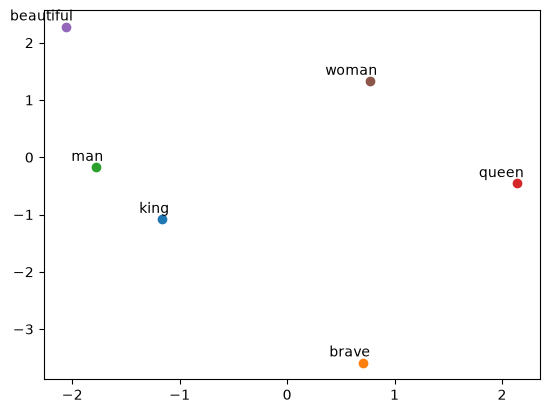

In [ ]:
# 실습 2-2 그래프로 비교해보기

for i, label in enumerate(tkn.word_index):     # tkn.word_index를 다시 같은 순서로 순회, i=0,1,2...는 "몇 번째 단어인지"
    print(i, label)                             
    x,y = pred[i]                              # pred는 x_test와 완전히 같은 순서로 만들어졌으므로, i번째 pred = i번째 단어의 임베딩 좌표
    print(x,y)
    plt.scatter(x,y)
    plt.annotate(label, xy=(x,y), xytext=(5,2),
                 textcoords= 'offset points', ha = 'right', va='bottom') # 점 옆에 단어 이름을 라벨로 붙임

plt.show()

## 2. Imdb 실습

In [26]:
# 실습 1-0 데이터 준비

(x_train, y_train), (x_test, y_test) = imdb.load_data()
print(x_train.shape, y_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(25000,) (25000,)


In [28]:
# 실습 1-1 데이터 확인

idx2wd = {idx:wd for wd, idx in imdb.get_word_index().items()}
for id in x_train[0]:
    print(idx2wd[id], end=" ")


the as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room titillate it so heart shows to years of every never going villaronga help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but pratfalls to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other tricky in of seen over landed for anyone of gilmore's br show's to whether from than out themselves history he name half some br of 'n odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but whe